In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, Xception, EfficientNetV2S, VGG16
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import classification_report
import warnings
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score
)
import seaborn as sns
warnings.filterwarnings("ignore")

## Load dataset
dataset contains pf header info

This dataset contains headers of 1986 binary executable 

In [2]:
df = pd.read_csv('pe_headers.csv')

In [3]:
# preview data
df.head()

,GR,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
2,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
4,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# PE Header 1024
df.iloc[:, 1:]

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
3,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
4,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1981,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1982,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1983,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.sample(9,random_state=42)

,GR,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
582,0,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1711,1,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1052,1,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1075,1,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
917,0,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
70,0,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
429,0,77,90,144,0,3,0,0,0,4,...,5,0,0,50,17,0,38,17,0,221
903,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
914,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


### Plot sample images

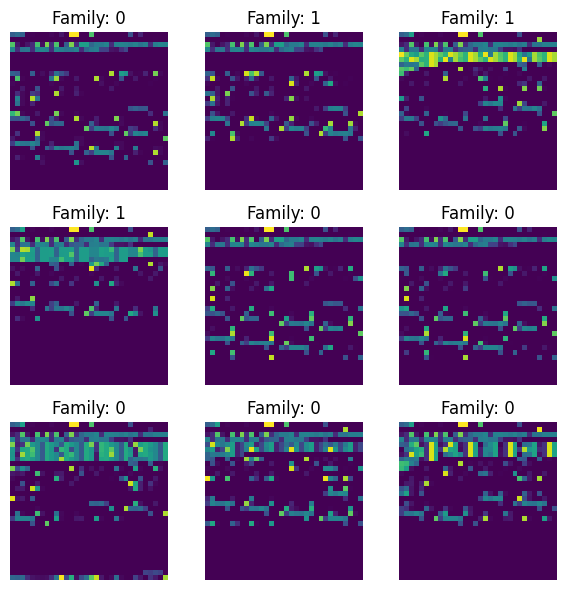

In [6]:
samp  = df.sample(9,random_state=42)
# Convert the numerical columns to color images
samp_images = samp.iloc[:, 1:].values.reshape(-1, 32, 32,1)
# Normalize the image values to [0, 1]
samp_images = samp_images / 255.0

# Create a new figure and plot the images
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

# Flatten the axes array to make it easier to iterate over
axes = axes.flatten()

# Iterate over each image and plot it
for i in range(len(axes)):
    ax = axes[i]
    ax.imshow(samp_images[i], cmap='viridis')  # Assuming grayscale images
    ax.axis('off')  # Turn off axis labels
    ax.set_title(f'Family: {samp.iloc[i, 0]}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Convert to colored and Split data

In [7]:
# Split the data into training and validation sets (70% for training, 20% for validation, 10% for test)
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(val_df, test_size=0.33, random_state=42)

# Convert the numerical columns to image
train_images = train_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)
val_images = val_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)
test_images = test_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)

# Normalize the image values to [0, 1]
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

# Convert the numerical columns to color images
train_images = np.repeat(train_images, 3, axis=3)
val_images = np.repeat(val_images, 3, axis=3)
test_images = np.repeat(test_images, 3, axis=3)

In [8]:
# Reshape each image in train_images to (256, 256, 3)
train_images = tf.image.resize(train_images, (256, 256))

# Reshape each image in val_images to (256, 256, 3)
val_images = tf.image.resize(val_images, (256, 256))

# Reshape each image in test_images to (256, 256, 3)
test_images = tf.image.resize(test_images, (256, 256))

## Build Resnet model for Goodware and randsomeware detection

In [9]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values